# Simulation results — figures for Section 4.3.1

Reads `Simulation_output_redo.csv`. Uses the corrected MPM `|MPM - Mean|`.

Only the two figures used in the *General observations* section are produced,
both contrasting a mild sea state (Hs = 2 m) with an extreme one (Hs = 8 m):

1. **MPM vs Tp per wave direction**, low damping case — shows the resonant
   peak in pitch/roll and the direction dependence.
2. **Relative and absolute MPM difference vs the low damping case** — shows
   how little the damping cases differ under mild conditions and how the
   difference grows under extreme conditions.

The Hs = 8 column spans fewer Tp values, so its subplot is drawn narrower.
Each Hs column uses its own (free) y-axis.

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TITLE_SIZE = 18
LABEL_SIZE = 16
TICK_SIZE = 14

plt.rcParams.update({
    'axes.titlesize': TITLE_SIZE,
    'axes.labelsize': LABEL_SIZE,
    'xtick.labelsize': TICK_SIZE,
    'ytick.labelsize': TICK_SIZE,
    'legend.fontsize': TICK_SIZE,
    'figure.titlesize': TITLE_SIZE,
})

In [29]:
df = pd.read_csv('Simulation_output_redo.csv')

# rename the calibrated 'best per DOF' case to 'average' for readability
for col in ['Damp_Heave', 'Damp_Roll', 'Damp_Pitch']:
    df[col] = df[col].replace({'DOFbest': 'average'})

# corrected MPM: magnitude of the response about its equilibrium
for suffix in ['Z', 'pitch', 'roll']:
    df[f'MPM {suffix} corr'] = (df[f'MPM {suffix}'] - df[f'Mean {suffix}']).abs()

DOFS = [
    {'key': 'Z',     'name': 'Heave', 'unit': 'm',   'drop_dirs': []},
    {'key': 'pitch', 'name': 'Pitch', 'unit': 'deg', 'drop_dirs': []},
    {'key': 'roll',  'name': 'Roll',  'unit': 'deg', 'drop_dirs': [0,180]},
]

DAMPING_COLORS = {
    'low':      '#1f77b4',
    'linhigh':  '#ff7f0e',
    'quadhigh': '#2ca02c',
    'average':  '#d62728',
}

# the two sea states contrasted in 4.3.1: mild vs extreme
HS_PAIR = [2, 8]

# one colour per wave direction for the directions figure
DIRECTIONS = sorted(df['Direction'].unique())
DIR_COLORS = {d: c for d, c in zip(DIRECTIONS, plt.cm.viridis(np.linspace(0, 0.9, len(DIRECTIONS))))}

def damping_col(dof_key):
    return {'Z': 'Damp_Heave', 'pitch': 'Damp_Pitch', 'roll': 'Damp_Roll'}[dof_key]

def filter_dirs(sub, dof):
    if dof['drop_dirs']:
        sub = sub[~sub['Direction'].isin(dof['drop_dirs'])]
    return sub

def tp_count(df, hs):
    # number of distinct Tp values for this Hs (drives subplot width)
    return df[df['Hs'] == hs]['Tp'].nunique()

print('Hs in pair:', HS_PAIR)
print('Directions:', DIRECTIONS)
print('Tp count per Hs:', {hs: tp_count(df, hs) for hs in HS_PAIR})

Hs in pair: [2, 8]
Directions: [np.int64(0), np.int64(45), np.int64(90), np.int64(135), np.int64(180)]
Tp count per Hs: {2: 13, 8: 5}


## Figure 1 — MPM vs Tp per direction (low damping), Hs = 2 vs Hs = 8

3 rows (DOFs) x 2 columns (Hs). One line per wave direction. Low damping only.
For roll, the 0 and 180 directions are dropped (waves parallel to the roll
axis, negligible response). Free y-axis per column.

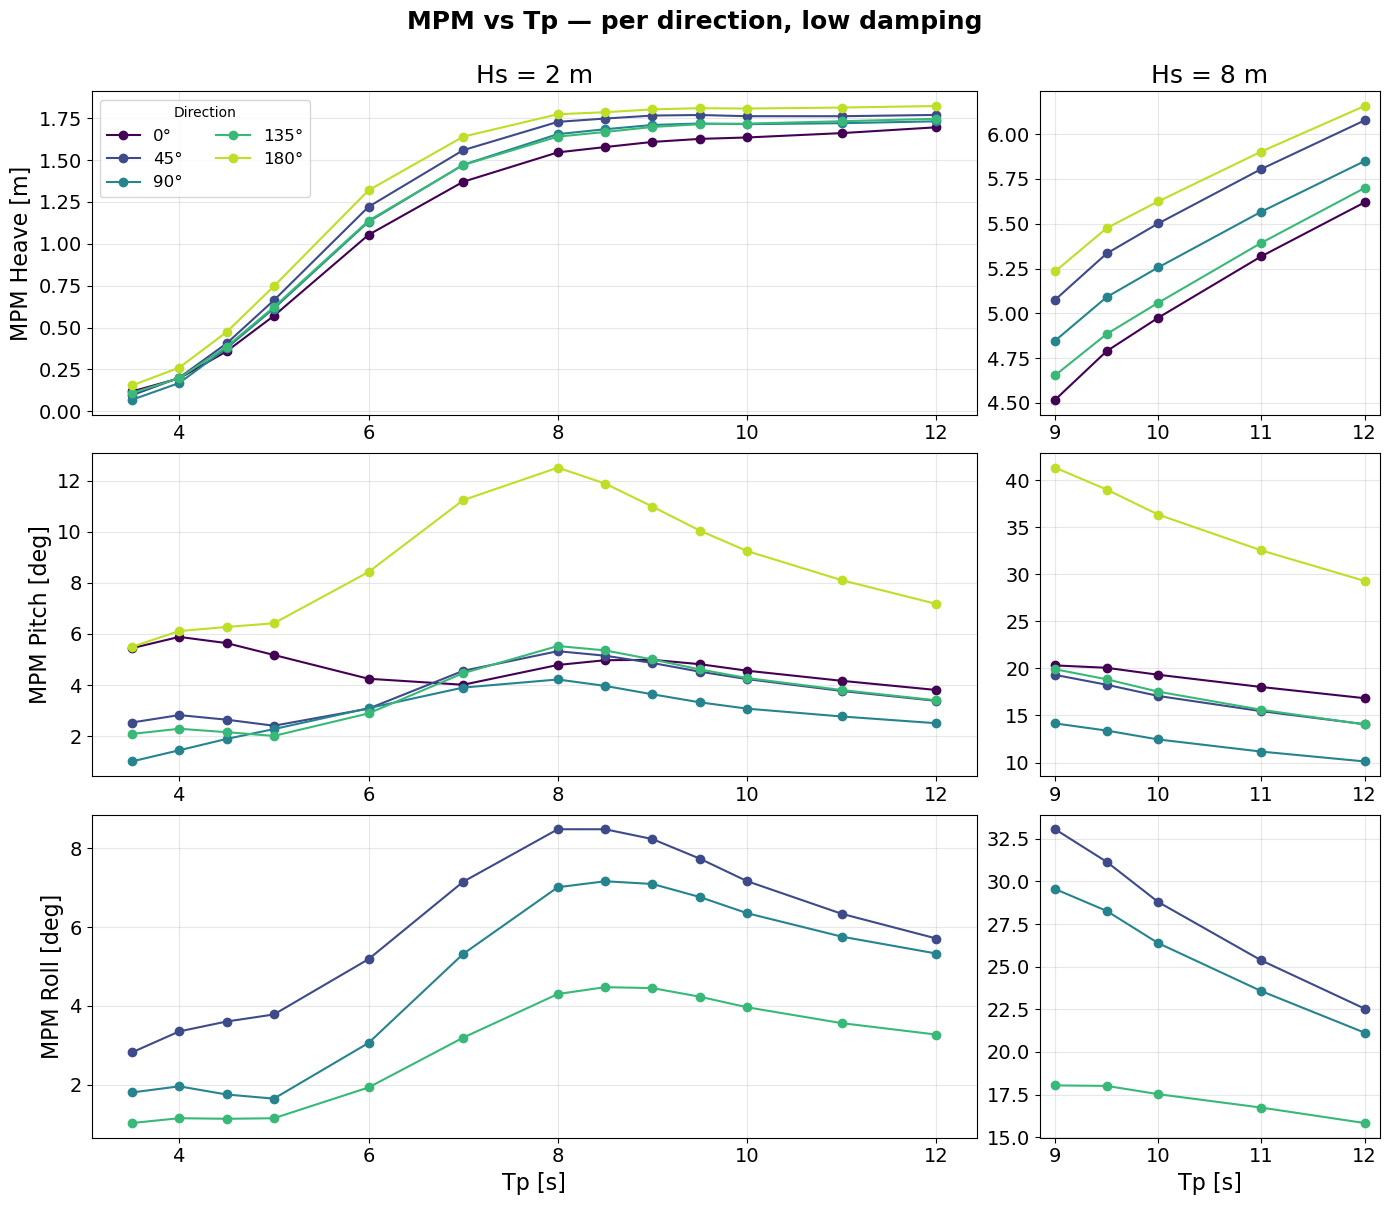

In [30]:
CHOICE = 'low'   # damping case shown in the directions figure

ncols = len(HS_PAIR)
widths = [tp_count(df, hs) for hs in HS_PAIR]
fig, axes = plt.subplots(3, ncols, figsize=(7 * ncols, 12),
                         squeeze=False,
                         gridspec_kw={'width_ratios': widths})

for c, hs in enumerate(HS_PAIR):
    sub_hs = df[(df['Hs'] == hs) & (df['Damp_Heave'] == CHOICE)]
    for r, dof in enumerate(DOFS):
        sub_dof = filter_dirs(sub_hs, dof)
        mpm_c = f'MPM {dof["key"]} corr'
        ax = axes[r, c]

        for direction in DIRECTIONS:
            if dof['drop_dirs'] and direction in dof['drop_dirs']:
                continue
            sub_dir = sub_dof[sub_dof['Direction'] == direction].sort_values('Tp')
            if sub_dir.empty:
                continue
            ax.plot(sub_dir['Tp'], sub_dir[mpm_c], 'o-',
                    label=f'{direction}\u00b0', color=DIR_COLORS[direction])

        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='both', labelsize=TICK_SIZE)
        if c == 0:
            ax.set_ylabel(f'MPM {dof["name"]} [{dof["unit"]}]', fontsize=LABEL_SIZE)
        if r == 0:
            ax.set_title(f'Hs = {hs} m', fontsize=TITLE_SIZE)
            
        if r == 0 and c == 0:
            ax.legend(title='Direction', ncol=2, fontsize=TICK_SIZE - 2)
        if r == 2:
            ax.set_xlabel('Tp [s]', fontsize=LABEL_SIZE)

fig.suptitle('MPM vs Tp \u2014 per direction, low damping', y=1.00, fontweight='bold')
fig.tight_layout( w_pad=1.6, h_pad=0.7)
fig.savefig('fig_directions_Hs2_Hs8.png', dpi=200, bbox_inches='tight')
plt.show()

## Figure 2 — Relative and absolute MPM difference vs low damping, Hs = 2 vs Hs = 8

3 rows (DOFs) x 2 columns (Hs). Solid lines (left axis) = relative reduction
[%]; dashed lines (right axis) = absolute reduction. Directions are averaged
(roll excludes 0 and 180). Free y-axis per column.

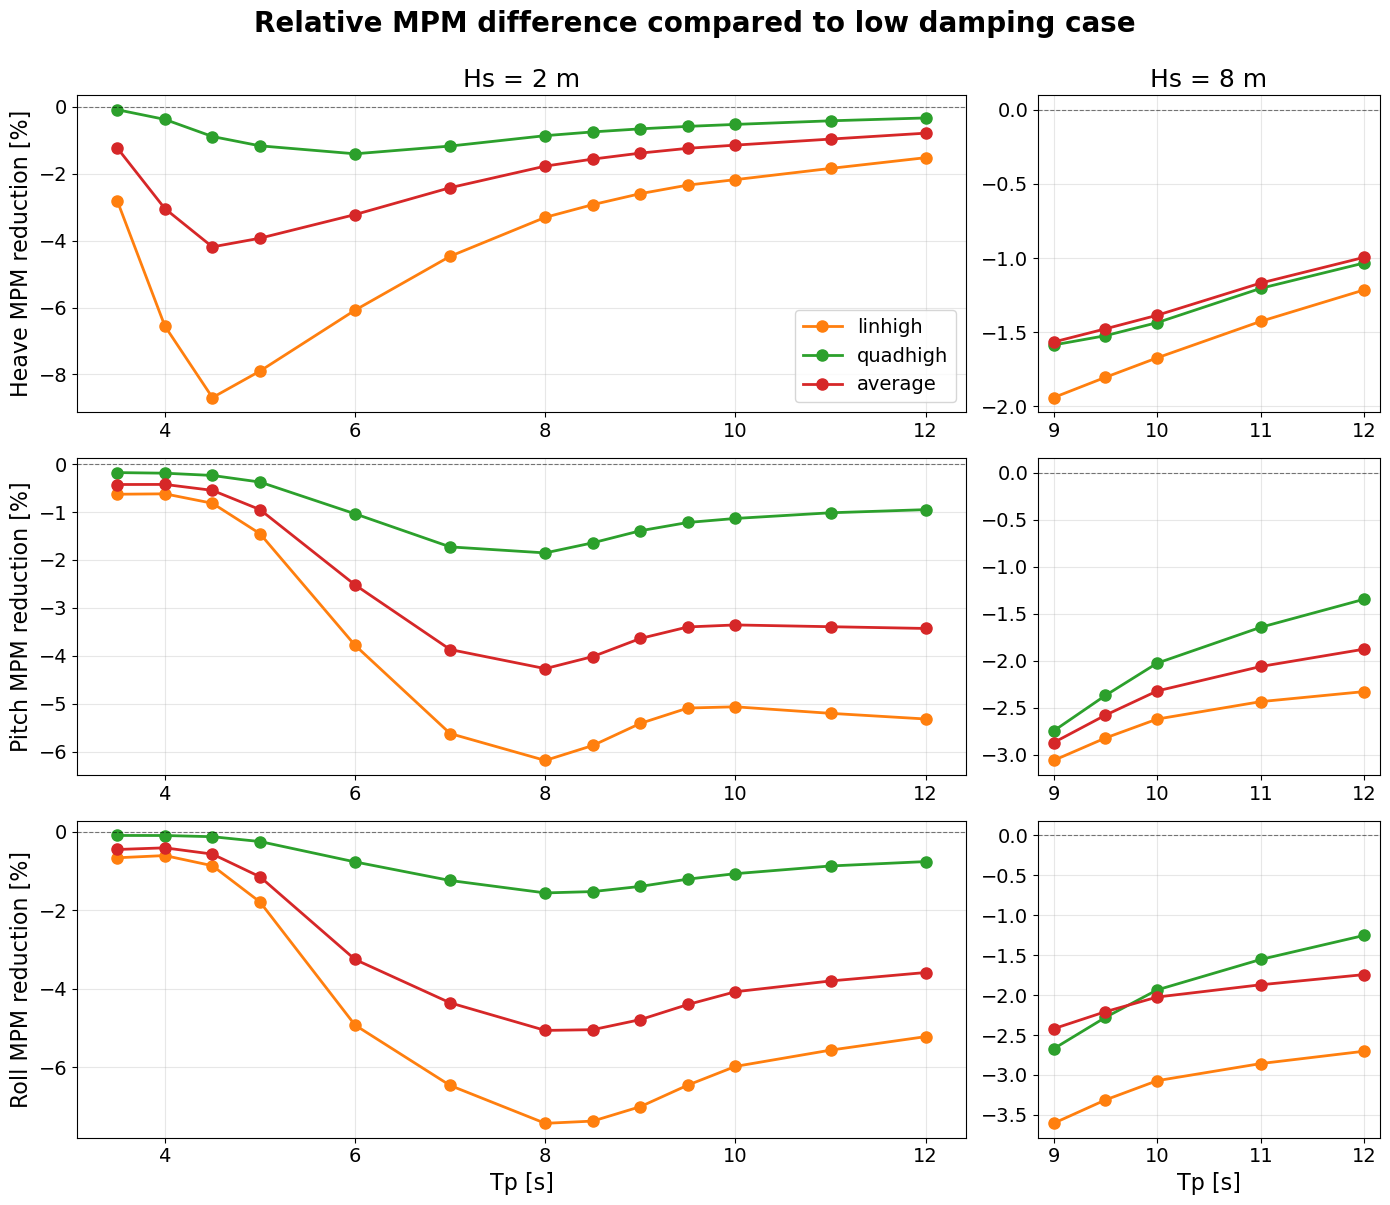

In [31]:
ncols = len(HS_PAIR)
widths = [tp_count(df, hs) for hs in HS_PAIR]
fig, axes = plt.subplots(3, ncols, figsize=(7 * ncols, 12),
                         squeeze=False,
                         gridspec_kw={'width_ratios': widths})

for c, hs in enumerate(HS_PAIR):
    sub_hs = df[df['Hs'] == hs]
    for r, dof in enumerate(DOFS):
        ax = axes[r, c]          # relative difference [%]
        sub_dof = filter_dirs(sub_hs, dof)
        dcol = damping_col(dof['key'])
        mpm_c = f'MPM {dof["key"]} corr'

        base = sub_dof[sub_dof[dcol] == 'low'].groupby('Tp')[mpm_c].mean().sort_index()

        for case in ['linhigh', 'quadhigh', 'average']:
            sub_case = sub_dof[sub_dof[dcol] == case]
            if sub_case.empty:
                continue
            grouped = sub_case.groupby('Tp')[mpm_c].mean().sort_index()
            common = grouped.index.intersection(base.index)
            if len(common) == 0:
                continue

            pct = (grouped.loc[common] - base.loc[common]) / base.loc[common] * 100

            ax.plot(common, pct, 'o-', label=case,
                    color=DAMPING_COLORS[case], linewidth=2, markersize=8)

        ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='both', labelsize=TICK_SIZE)
        if c == 0:
            ax.set_ylabel(f'{dof["name"]} MPM reduction [%]', fontsize=LABEL_SIZE)

        if r == 0:
            ax.set_title(f'Hs = {hs} m', fontsize=TITLE_SIZE)
        if r == 0 and c == 0:
            ax.legend(fontsize=TICK_SIZE)
        if r == 2:
            ax.set_xlabel('Tp [s]', fontsize=LABEL_SIZE)

fig.suptitle('Relative MPM difference compared to low damping case',
             y=1.00, fontsize=TITLE_SIZE + 2, fontweight='bold')
fig.tight_layout()
fig.savefig('fig_reduction_Hs2_Hs8.png', dpi=200, bbox_inches='tight')
plt.show()
